# Отток клиентов

Из «Бета-Банка» стали уходить клиенты. Каждый месяц. Немного, но заметно. Банковские маркетологи посчитали: сохранять текущих клиентов дешевле, чем привлекать новых.

Нужно спрогнозировать, уйдёт клиент из банка в ближайшее время или нет. Вам предоставлены исторические данные о поведении клиентов и расторжении договоров с банком. 

Постройте модель с предельно большим значением *F1*-меры. Чтобы сдать проект успешно, нужно довести метрику до 0.59. Проверьте *F1*-меру на тестовой выборке самостоятельно.

Дополнительно измеряйте *AUC-ROC*, сравнивайте её значение с *F1*-мерой.

***Признаки***

    RowNumber — индекс строки в данных
    CustomerId — уникальный идентификатор клиента
    Surname — фамилия
    CreditScore — кредитный рейтинг
    Geography — страна проживания
    Gender — пол
    Age — возраст
    Tenure — сколько лет человек является клиентом банка
    Balance — баланс на счёте
    NumOfProducts — количество продуктов банка, используемых клиентом
    HasCrCard — наличие кредитной карты
    IsActiveMember — активность клиента
    EstimatedSalary — предполагаемая зарплата

***Целевой признак***

    Exited — факт ухода клиента

## Подготовка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle
from itertools import product

In [2]:
df = pd.read_csv('/datasets/Churn.csv')

Посмотрим на первые 5 строк таблицы и информацию о ней.

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             9091 non-null float64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


Типы данных столбцов верны. Но мы замечаем пропуски в столбце Tenure. Заполним их нетральным значением -1

In [5]:
df['Tenure'] = df['Tenure'].fillna(-1)

Проверим таблицу на наличие дубликатов и пропусков.

In [6]:
df.duplicated().sum()

0

In [7]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Дубликатов нет. Пропусков нет.

Замечаем, что целевой признак Exited - это категориальный признак, поэтому мы будем использовать методы классификации. А также столбцы RowNumber, CustomerId и Surname - это  столбцы-идентификаторы, в дальнейшем они не понадобятся для машинного обучения. Создадим новую таблицу без этих столбцов.

In [8]:
df_new=df.drop(['RowNumber','CustomerId', 'Surname'], axis=1)

Посмотрим на новую таблицу

In [9]:
df_new.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [10]:
df_new.shape

(10000, 11)

In [11]:
df_new['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [12]:
df_new['Gender'].unique()

array(['Female', 'Male'], dtype=object)

У стотлбца Gender всего 2 уникальных значения, у Geography - 3. Данные подготовим методом OHE, чтобы избежать дами-ловушки.

In [13]:
df_new = pd.get_dummies(df_new, drop_first=True)

Посмотрим на таблицу

In [14]:
df_new.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1.0,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8.0,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1.0,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2.0,125510.82,1,1,1,79084.10,0,0,1,0


In [15]:
df_new.shape

(10000, 12)

Получилось 12 столбцов, вместо 11.

Разделим на признаки и целевой признак

In [16]:
features = df_new.drop('Exited', axis=1)
target = df_new['Exited']

Разделим данные на три выборки:

    обучающая 60% 
    валидационная 20% 
    тестовая 20% 

In [17]:
features_train, features_testvalid, target_train, target_testvalid = train_test_split(features,
                                                    target,
                                                    train_size=0.6,
                                                    random_state=12345, 
                                                    stratify=target)

features_valid, features_test, target_valid, target_test = train_test_split(features_testvalid,
                                                    target_testvalid,
                                                    train_size=0.5,
                                                    random_state=12345, 
                                                    stratify=target_testvalid)

In [18]:
print('Признаки обучающей выборки:\n',features_train.shape)
print('Целевой признак обучающей выборки:\n', target_train.shape) 
print('Признаки валидационной выборки:\n',features_valid.shape)  
print('Целевой признак валидационной выборки:\n', target_valid.shape) 
print('Признаки тестовой выборки:\n',features_test.shape)  
print('Целевой признак тестовой выборки:\n', target_test.shape)

Признаки обучающей выборки:
 (6000, 11)
Целевой признак обучающей выборки:
 (6000,)
Признаки валидационной выборки:
 (2000, 11)
Целевой признак валидационной выборки:
 (2000,)
Признаки тестовой выборки:
 (2000, 11)
Целевой признак тестовой выборки:
 (2000,)


Для стандартизации в переменной numeric сохраним названия численных столбцов 

In [19]:
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

In [20]:
scaler = StandardScaler()
scaler.fit(features_train[numeric])

StandardScaler(copy=True, with_mean=True, with_std=True)

Стандартизируем численные признаки обучающей выборки и посмотрим на них

In [21]:
features_train[numeric] = scaler.transform(features_train[numeric])
features_train.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:494: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2837,-1.040434,0.953312,0.474986,0.774657,-0.914708,0,1,-0.119110,1,0,0
9925,0.454006,-0.095244,-1.675197,1.910540,-0.914708,1,1,-0.258658,0,0,0
8746,0.103585,-0.476537,1.089324,0.481608,0.820981,0,1,1.422836,0,0,1
660,-0.184996,0.190726,-1.675197,0.088439,-0.914708,1,1,-1.160427,1,0,0
3610,-0.720933,1.620574,-1.060859,0.879129,-0.914708,1,0,0.113236,0,0,0


Стандартизируем численные признаки валидационной выборки и посмотрим на них

In [22]:
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_valid.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:494: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6612,-1.524838,2.383160,-0.446521,1.011655,-0.914708,0,1,0.010275,0,0,0
519,0.587990,1.811221,0.474986,0.213192,-0.914708,0,1,0.453089,0,0,1
1609,-0.318980,-0.381213,1.089324,0.893896,-0.914708,1,0,-0.603508,0,0,0
3475,1.226991,-0.762506,-0.139352,-0.240363,0.820981,1,1,-1.621460,0,0,1
2707,-0.133464,-0.095244,-0.446521,0.447305,-0.914708,0,0,0.338574,0,0,0


Стандартизируем численные признаки тестовой выборки и посмотрим на них

In [23]:
features_test[numeric] = scaler.transform(features_test[numeric])
features_test.head()

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:494: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[item] = s


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
657,-0.504497,1.429928,-1.060859,0.873883,0.820981,1,1,1.725255,1,0,0
2083,-1.195031,-1.429769,-1.060859,-1.219673,-0.914708,1,1,1.203665,0,0,1
3234,-1.267176,0.762665,-1.060859,-1.219673,-0.914708,1,0,-1.374743,0,0,1
1551,0.825039,1.239281,0.782155,-1.219673,0.820981,0,1,0.382306,0,1,0
2344,0.660135,0.953312,-0.139352,0.267087,-0.914708,1,0,-1.613578,1,0,0


 Мы подготовили данные. Перейдем к исследованию задачи


## Исследование задачи

**Характеристики разных моделей.**

Дерево решений

In [24]:
model_DT = DecisionTreeClassifier(random_state=123)
DT_score = model_DT.fit(features_train, target_train).score(features_valid, target_valid)
DT_prediction = model_DT.predict(features_valid)

In [25]:
print("Полнота" , recall_score(target_valid, DT_prediction))
print("Точность", precision_score(target_valid, DT_prediction))
print("F1-мера", f1_score(target_valid, DT_prediction))
print("AUC-ROC", roc_auc_score(target_valid, DT_prediction))

Полнота 0.5245098039215687
Точность 0.4965197215777262
F1-мера 0.5101311084624552
AUC-ROC 0.694101635629126


Случайный лес

In [26]:
model_RF = RandomForestClassifier(random_state=12345)
RF_score = model_RF.fit(features_train, target_train).score(features_valid, target_valid)
RF_prediction = model_RF.predict(features_valid)

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [27]:
print("Полнота" , recall_score(target_valid, RF_prediction))
print("Точность", precision_score(target_valid, RF_prediction))
print("F1-мера", f1_score(target_valid, RF_prediction))
print("AUC-ROC", roc_auc_score(target_valid, RF_prediction))

Полнота 0.45098039215686275
Точность 0.7330677290836654
F1-мера 0.5584218512898331
AUC-ROC 0.7044474825105921


Логическая регрессия.

In [28]:
model_LR = LogisticRegression(solver = 'liblinear')
LR_score = model_LR.fit(features_train, target_train).score(features_valid, target_valid)
LR_prediction = model_LR.predict(features_valid)

In [29]:
print("Полнота" , recall_score(target_valid, LR_prediction))
print("Точность", precision_score(target_valid, LR_prediction))
print("F1-мера", f1_score(target_valid, LR_prediction))
print("AUC-ROC", roc_auc_score(target_valid, LR_prediction))

Полнота 0.20588235294117646
Точность 0.6086956521739131
F1-мера 0.3076923076923077
AUC-ROC 0.5859813774756133


In [30]:
print("Accuracy разных моделей:");
print("дерево решений:", DT_score, "случайный лес:", RF_score, "логическая регрессия:", LR_score)

Accuracy разных моделей:
дерево решений: 0.7945 случайный лес: 0.8545 логическая регрессия: 0.811


Видим, что F1-мера меньше всего у логической регрессии(полнота тоже), а точность - у дерева решении. Больше всего F1 у случайного леса. Посмотрим на эти модели при разных параметрах.

In [31]:
best_result=0
f1=0
parametrs=['lbfgs', 'liblinear']
for x in parametrs:
        model_LR = LogisticRegression(solver = x)
        model_LR.fit(features_train, target_train)
        predictions = model_LR.predict(features_valid)
        f1 = f1_score(target_valid, predictions)
        if f1 > best_result:
            best_result=f1
            best_solver=x
print('Логическая регрессия. Наилучшая модель f1 =', best_result,'( при solver =', best_solver,' )')

Логическая регрессия. Наилучшая модель f1 = 0.3076923076923077 ( при solver = liblinear  )


In [32]:
maxim_est=0
maxim_depth=0
best_result=0
f1=0
for est in range(20,31,2):
    for depth in range(1,11):
            model = RandomForestClassifier(max_depth = depth, n_estimators = est, random_state=12345)
            model.fit(features_train, target_train)
            predictions = model.predict(features_valid)
            f1 = f1_score(target_valid, predictions)
            if f1 > best_result:
                best_result=f1
                maxim_depth=depth
                maxim_est=est
print('Случайный лес. Наилучшая модель f1 =', best_result,'( при depth =',maxim_depth,'и estimator =',maxim_est,' )')

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)
/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-sco

Случайный лес. Наилучшая модель f1 = 0.6052227342549923 ( при depth = 9 и estimator = 22  )


In [33]:
maxim_depth=0
best_result=0
f1=0
for depth in range(1,20):
    model_DT = DecisionTreeClassifier(random_state=123, max_depth=depth)
    model_DT.fit(features_train, target_train)
    predictions = model_DT.predict(features_valid)
    f1 = f1_score(target_valid, predictions)
    if f1 > best_result:
        best_result=f1
        maxim_depth=depth
print('Дерево решений. Наилучшая модель f1 =', best_result,'( при depth =', maxim_depth,' )')

/opt/conda/lib/python3.7/site-packages/sklearn/metrics/classification.py:1437: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no predicted samples.
  'precision', 'predicted', average, warn_for)


Дерево решений. Наилучшая модель f1 = 0.5945165945165946 ( при depth = 7  )


Видим, что больше всего мера f1 у случайного леса при depth = 9 и estimator = 22. Пока это наилучшая модель. Посмотрим на ее другие характеристики.

In [34]:
model_RF_best = RandomForestClassifier(max_depth = 9, n_estimators = 22, random_state=12345)
model_RF_best.fit(features_train, target_train)
RF_prediction_best = model_RF_best.predict(features_valid)
print("Полнота" , recall_score(target_valid, RF_prediction_best))
print("Точность", precision_score(target_valid, RF_prediction_best))
print("F1-мера", f1_score(target_valid, RF_prediction_best))
print("AUC-ROC", roc_auc_score(target_valid, RF_prediction_best))

Полнота 0.48284313725490197
Точность 0.8106995884773662
F1-мера 0.6052227342549923
AUC-ROC 0.7269743324465465


**Проверка баланса классов выборки**

Обучающая выборка

In [35]:
target_train.value_counts(normalize = 1)

0    0.796333
1    0.203667
Name: Exited, dtype: float64

Валидационная выборка

In [36]:
target_valid.value_counts(normalize = 1)

0    0.796
1    0.204
Name: Exited, dtype: float64

У обучающией и валидационной выборок наблюдается заметный дисбаланс классов. 
Ответы 0 (примерно 80%), 1 (примерно 20%)
Возможно результаты предсказаний моделей будут сильно склоняться к одному варианту ответа.

**Проверка адекватности**

Проверим какое соотношение ответов выдает каждая модель.

Дерево решений

In [37]:
model_DT = DecisionTreeClassifier(random_state=123)
model_DT.fit(features_train, target_train)
DT_share = pd.Series(model_DT.predict(features_valid)).value_counts(normalize = 1)  

Случайный лес

In [38]:
model_RF = RandomForestClassifier(random_state=12345)
model_RF.fit(features_train, target_train)
RF_share = pd.Series(model_RF.predict(features_valid)).value_counts(normalize = 1)   

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [39]:
model_RF_best = RandomForestClassifier(max_depth = 9, n_estimators = 22, random_state=12345)
model_RF_best.fit(features_train, target_train)
RF_share_best = pd.Series(model_RF_best.predict(features_valid)).value_counts(normalize = 1)  

Логическая регрессия

In [40]:
model_LR = LogisticRegression(solver = 'liblinear')
model_LR.fit(features_train, target_train)
LR_share = pd.Series(model_LR.predict(features_valid)).value_counts(normalize = 1)

In [41]:
print("Доли ответов разных моделей:") 
print("дерево решений:")
print(DT_share)
print("случайный лес:")
print(RF_share)
print("логическая регрессия:")
print(LR_share)
print("случайный лес. Наилучшая модель:")
print(RF_share_best)

Доли ответов разных моделей:
дерево решений:
0    0.7845
1    0.2155
dtype: float64
случайный лес:
0    0.8745
1    0.1255
dtype: float64
логическая регрессия:
0    0.931
1    0.069
dtype: float64
случайный лес. Наилучшая модель:
0    0.8785
1    0.1215
dtype: float64


Случайный лес показывал самую высокую точность, но данная модель скорее выдает одинаковый результат = 0(примерно 87 процентов). У всех моделей наблюдается дисбаланс классов.
Сравним качество предсказаний с константной моделью. 
За константу примем пример 0, так как это значение встречается 80% случаев.

Создаем константную модель

In [42]:
target_predict_constant = pd.Series([0]*len(target_valid))
target_predict_constant.shape

(2000,)

Посчитаем точность модели

In [43]:
accuracy_score_constant = accuracy_score(target_valid, target_predict_constant)
accuracy_score_constant

0.796

Точность не высокая, по сравнению с точностью моделей случайный лес, логическая регрессия и дерево решений. Вероятно проблема кроется в дисбалансе классов. *Ознакомися с матрицой ошибок для каждой модели:*

**Дерево решений**

In [44]:
model_DT = DecisionTreeClassifier(random_state=123)
model_DT.fit(features_train, target_train)
DT_prediction = model_DT.predict(features_valid)
confusion_matrix(target_valid, DT_prediction)

array([[1375,  217],
       [ 194,  214]])

Дерево решений склонно выдавать больше истинно отрицательные ответы, положительных ответов мало, а истинно положительных вообще всего  214. 
Изучим полноту, точность и F1-меру (для этого напишем функцию)

In [45]:
def recall_prec_f1(target_valid, prediction):
    print("Полнота" , recall_score(target_valid, prediction))
    print("Точность", precision_score(target_valid, prediction))
    print("F1-мера", f1_score(target_valid, prediction))
    print("AUC-ROC", roc_auc_score(target_valid, prediction))

In [46]:
recall_prec_f1(target_valid, DT_prediction)

Полнота 0.5245098039215687
Точность 0.4965197215777262
F1-мера 0.5101311084624552
AUC-ROC 0.694101635629126


Низкое значние F1- меры свидетельствует о низком качестве модели.
Посмотрим на AUC-ROC модели, построим график 

In [47]:
DT_probabilities_one_valid = model_DT.predict_proba(features_valid)[:, 1]

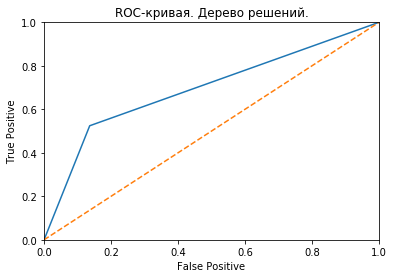

In [48]:
fpr, tpr, thresholds = roc_curve(target_valid, DT_probabilities_one_valid) 

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-кривая. Дерево решений.')
plt.show()

Попробуем обучить модель, сбалансировав классы. Построим график.

Score 0.7975
AUC-ROC 0.6877832791408021


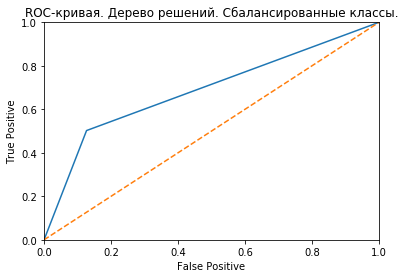

In [49]:
model_DT = DecisionTreeClassifier(random_state=123, class_weight='balanced')
model_DT.fit(features_train, target_train)
DT_probabilities_one_valid_class_weight = model_DT.predict_proba(features_valid)[:, 1]
print("Score", model_DT.score(features_valid, target_valid))
print("AUC-ROC", roc_auc_score(target_valid, DT_probabilities_one_valid_class_weight))

fpr, tpr, thresholds = roc_curve(target_valid, DT_probabilities_one_valid_class_weight) 
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-кривая. Дерево решений. Сбалансированные классы.')
plt.show()

Точность предсказаний улучшилась, а AUC-ROC уменьшилась. Высокая точность модели объясняется высокой долей негативных ответов в валидационной выборке.

**Случайный лес**

In [50]:
model_RF = RandomForestClassifier(random_state=12345)
model_RF.fit(features_train, target_train)
RF_prediction = model_RF.predict(features_valid)
confusion_matrix(target_valid, RF_prediction)

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


array([[1525,   67],
       [ 224,  184]])

Истинно положительных ответом еще меньше, чем у модели Дерево решений, а истинно отрицательных еще больше.
Посмотрим на различные метрики:

In [51]:
recall_prec_f1(target_valid, RF_prediction)

Полнота 0.45098039215686275
Точность 0.7330677290836654
F1-мера 0.5584218512898331
AUC-ROC 0.7044474825105921


F1 также очень низкое.

In [52]:
RF_probabilities_one_valid = model_RF.predict_proba(features_valid)[:, 1]

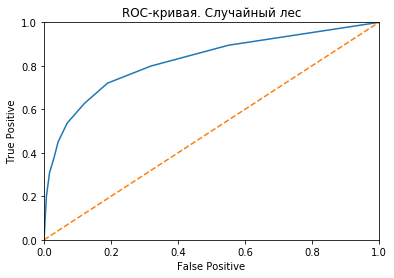

In [53]:
fpr, tpr, thresholds = roc_curve(target_valid, RF_probabilities_one_valid) 

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-кривая. Случайный лес')
plt.show()

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


Score 0.857
AUC-ROC 0.830632174352153


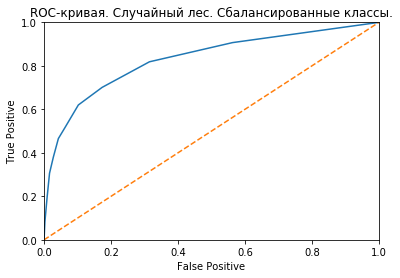

In [54]:
model_RF = RandomForestClassifier(random_state=12345, class_weight='balanced')
model_RF.fit(features_train, target_train)
RF_probabilities_one_valid_class_weight = model_RF.predict_proba(features_valid)[:, 1]
print("Score", model_RF.score(features_valid, target_valid))
print("AUC-ROC", roc_auc_score(target_valid, RF_probabilities_one_valid_class_weight))

fpr, tpr, thresholds = roc_curve(target_valid, RF_probabilities_one_valid_class_weight) 
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-кривая. Случайный лес. Сбалансированные классы.')
plt.show()

AUC-ROC - метрика качества классификации и она увеличилась. И точность тоже.

**Логическая регрессия**

In [55]:
model_LR = LogisticRegression(solver = 'liblinear')
model_LR.fit(features_train, target_train)
LR_prediction = model_LR.predict(features_valid)
confusion_matrix(target_valid, LR_prediction)

array([[1538,   54],
       [ 324,   84]])

В данной моделе меньше всего положительных ответов. Истинно отрицательных больше всего 

In [56]:
recall_prec_f1(target_valid, LR_prediction)

Полнота 0.20588235294117646
Точность 0.6086956521739131
F1-мера 0.3076923076923077
AUC-ROC 0.5859813774756133


У Логической регрессии самое маленькое значение F1-меры. Это свидетельствует об очень низком качестве модели.

In [57]:
LR_probabilities_one_valid = model_LR.predict_proba(features_valid)[:, 1]

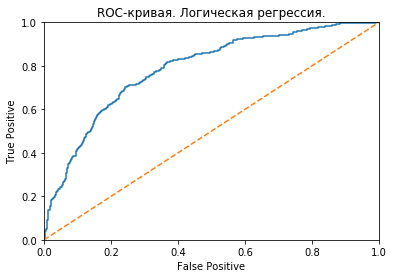

In [58]:
fpr, tpr, thresholds = roc_curve(target_valid, LR_probabilities_one_valid) 

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-кривая. Логическая регрессия.')
plt.show()

Score 0.733
AUC-ROC 0.7938097349492561


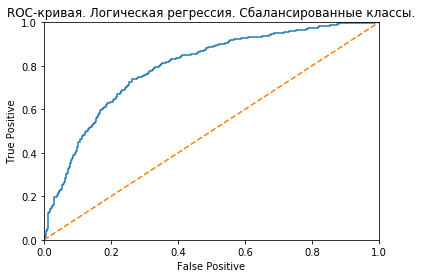

In [59]:
model_RF = LogisticRegression(solver = 'liblinear', class_weight='balanced')
model_RF.fit(features_train, target_train)
RF_probabilities_one_valid_class_weight = model_RF.predict_proba(features_valid)[:, 1]
print("Score", model_RF.score(features_valid, target_valid))
print("AUC-ROC", roc_auc_score(target_valid, RF_probabilities_one_valid_class_weight))

fpr, tpr, thresholds = roc_curve(target_valid, RF_probabilities_one_valid_class_weight) 
plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive')
plt.ylabel('True Positive')
plt.title('ROC-кривая. Логическая регрессия. Сбалансированные классы.')
plt.show()

И точность и AUC-ROC увеличилась

*Мы обучили модели, посмотрели на их характеристики. Построили графики. Сравнили с константной моделью.Значительный дисбаланс (80% ответов целевого признака негативные и только 20% позитивные), из-за чего обученная на этих данных модель не проходит проверку на адекватность. Все модели характеризуются низким качеством.*
Перейдем к формированию сбалансированных выборок

## Борьба с дисбалансом

Как мы выяснили ранее в нашей выборке отрицательны ответов ≈80% , положитительных ≈ 20%.
Нам необходмо увеличить количество положительных ответов в 4 раза для достижения баланса.

    Разделим обучающую выборку на отрицательные и положительные объекты;
    Скопируем несколько раз положительные объекты;
    С учётом полученных данных создадим новую обучающую выборку;
    Перемешаем данные
    Обучим новые модели

Первоначальное распределение классов:

In [60]:
target_train.value_counts(normalize = 1)

0    0.796333
1    0.203667
Name: Exited, dtype: float64

In [61]:
target_train.shape

(6000,)

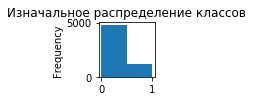

In [62]:
target_train.plot(kind ='hist', bins=2, figsize=(1,1), title='Изначальное распределение классов')

Напишем функцию для увеличения класса в выборке

In [63]:
def upsample(features, target, repeat, upsampled_сlass):
    features_zeros = features[target == 0]
    features_ones = features[target == 1]
    target_zeros = target[target == 0]
    target_ones = target[target == 1]
    if upsampled_сlass == 0:
        features_upsampled = pd.concat([features_zeros]* repeat + [features_ones] )
        target_upsampled = pd.concat([target_zeros]* repeat + [target_ones] )
        features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345)
    elif upsampled_сlass == 1:
        features_upsampled = pd.concat([features_zeros] + [features_ones] * repeat)
        target_upsampled = pd.concat([target_zeros] + [target_ones] * repeat)
        features_upsampled, target_upsampled = shuffle(
        features_upsampled, target_upsampled, random_state=12345)
    else:
        features_upsampled = 0
        target_upsampled = 0  
    return features_upsampled, target_upsampled

Применим функцию, увеличим количество положительных ответов в 4 раза.

In [64]:
features_train_upsampled, target_train_upsampled = upsample(features_train, target_train, 4, 1)
print(target_train_upsampled.value_counts(normalize = 1))
print(target_train_upsampled.shape)

1    0.50569
0    0.49431
Name: Exited, dtype: float64
(9666,)


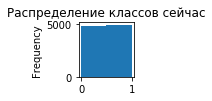

In [65]:
target_train_upsampled.plot(kind ='hist', bins=2, figsize=(1,1), title='Распределение классов сейчас')

Мы получили сбалансированное количество классов, перейдем к обучению моеделей на новы данных.

In [66]:
model_DT = DecisionTreeClassifier(random_state=123)
DT_score_new = model_DT.fit(features_train_upsampled, target_train_upsampled).score(features_valid, target_valid)

In [67]:
model_RF = RandomForestClassifier(random_state=12345)
RF_score_new = model_RF.fit(features_train_upsampled, target_train_upsampled).score(features_valid, target_valid)

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/forest.py:245: FutureWarning: The default value of n_estimators will change from 10 in version 0.20 to 100 in 0.22.
  "10 in version 0.20 to 100 in 0.22.", FutureWarning)


In [68]:
model_LR = LogisticRegression(solver = 'liblinear')
LR_score_new = model_LR.fit(features_train_upsampled, target_train_upsampled).score(features_valid, target_valid)

In [69]:
print("Accuracy разных моделей с дисбалансом:");
print("дерево решений:", DT_score, "случайный лес:", RF_score, "логическая регрессия:", LR_score)

Accuracy разных моделей с дисбалансом:
дерево решений: 0.7945 случайный лес: 0.8545 логическая регрессия: 0.811


In [70]:
print("Accuracy разных моделей на сбалансированной выборке:");
print("дерево решений:", DT_score_new, "случайный лес:", RF_score_new, "логическая регрессия:", LR_score_new)

Accuracy разных моделей на сбалансированной выборке:
дерево решений: 0.8065 случайный лес: 0.8525 логическая регрессия: 0.7255


Точность моделей изменились незначительно, но проверим изменилось ли качество ответов.

Дерево решений

In [71]:
model_DT_upsampled = DecisionTreeClassifier(random_state=123)
model_DT_upsampled.fit(features_train_upsampled, target_train_upsampled)
DT_prediction_upsampled = model_DT_upsampled.predict(features_valid)
recall_prec_f1(target_valid, DT_prediction_upsampled)

Полнота 0.5122549019607843
Точность 0.5264483627204031
F1-мера 0.5192546583850932
AUC-ROC 0.6970822248497388


Случайный лес

In [72]:
model_RF_upsampled = RandomForestClassifier(random_state=12345, n_estimators = 100)
model_RF_upsampled.fit(features_train_upsampled, target_train_upsampled)
RF_prediction_upsampled = model_RF_upsampled.predict(features_valid)
recall_prec_f1(target_valid, RF_prediction_upsampled)

Полнота 0.5759803921568627
Точность 0.6564245810055865
F1-мера 0.6135770234986945
AUC-ROC 0.7493595428120997


Логическая регрессия 

In [73]:
model_LR_upsampled = LogisticRegression(solver = 'liblinear')
model_LR_upsampled.fit(features_train_upsampled, target_train_upsampled)
LR_prediction_upsampled = model_LR_upsampled.predict(features_valid)
recall_prec_f1(target_valid, LR_prediction_upsampled)

Полнота 0.7426470588235294
Точность 0.40562248995983935
F1-мера 0.5246753246753246
AUC-ROC 0.7318762932308602


Показатели моделей улучшились. Лучшие результаты показывает случайный лес. F1 меры = 0.61.
Попробуем улучшить модели путем изменения параметров.

In [74]:
maxim_est=0
maxim_depth=0
best_result=0
f1=0
for est in range(20,31,2):
    for depth in range(1,11):
            model = RandomForestClassifier(max_depth = depth, n_estimators = est, random_state=12345)
            model.fit(features_train_upsampled, target_train_upsampled)
            predictions = model.predict(features_valid)
            f1 = f1_score(target_valid, predictions)
            if f1 > best_result:
                best_result=f1
                maxim_depth=depth
                maxim_est=est
print('Случайный лес. Наилучшая модель f1 =', best_result,'( при depth =',maxim_depth,'и estimator =',maxim_est,' )');

Случайный лес. Наилучшая модель f1 = 0.6376496191512514 ( при depth = 10 и estimator = 28  )


In [75]:
best_result=0
f1=0
parametrs=['lbfgs', 'liblinear']
for x in parametrs:
        model_LR = LogisticRegression(solver = x)
        model_LR.fit(features_train_upsampled, target_train_upsampled)
        predictions = model_LR.predict(features_valid)
        f1 = f1_score(target_valid, predictions)
        if f1 > best_result:
            best_result=f1
            best_solver=x
print('Логическая регрессия. Наилучшая модель f1 =', best_result,'( при solver =', best_solver,' )')

Логическая регрессия. Наилучшая модель f1 = 0.5246753246753246 ( при solver = liblinear  )


In [76]:
maxim_depth=0
best_result=0
f1=0
for depth in range(1,20):
    model_DT = DecisionTreeClassifier(random_state=123, max_depth=depth)
    model_DT.fit(features_train_upsampled, target_train_upsampled)
    predictions = model_DT.predict(features_valid)
    f1 = f1_score(target_valid, predictions)
    if f1 > best_result:
        best_result=f1
        maxim_depth=depth
print('Дерево решений. Наилучшая модель f1 =', best_result,'( при depth =', maxim_depth,' )')

Дерево решений. Наилучшая модель f1 = 0.575925925925926 ( при depth = 6  )


Лучшие результаты показывает случайный лес f1 = 0.6376496191512514 ( при depth = 10 и estimator = 28  )

Обучим финальную модель

In [77]:
model_RF_final = RandomForestClassifier(max_depth= 10,  n_estimators = 28, random_state=12345)
model_RF_final.fit(features_train_upsampled, target_train_upsampled)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
                       max_depth=10, max_features='auto', max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=28,
                       n_jobs=None, oob_score=False, random_state=12345,
                       verbose=0, warm_start=False)

In [78]:
model_RF_final_prediction = model_RF_final.predict(features_valid)
recall_prec_f1(target_valid, model_RF_final_prediction)

Полнота 0.7181372549019608
Точность 0.5733855185909981
F1-мера 0.6376496191512514
AUC-ROC 0.7906012907675634


Создадим константную модель и проверим модель на адекватность 

In [79]:
target_predict_constant = pd.Series([0]*len(target_valid))
target_predict_constant.value_counts()

0    2000
dtype: int64

Сравним показатель точности (accuracy_score) и AUC-ROC константной модели и финальной

In [80]:
print('accuracy_score константой модели:', accuracy_score(target_valid, target_predict_constant))
print('AUC-ROC константой модели:', roc_auc_score(target_valid, target_predict_constant))
print('accuracy_score финальной модели:', accuracy_score(target_valid, model_RF_final_prediction))
print('AUC-ROC финальной модели:', roc_auc_score(target_valid, model_RF_final_prediction))

accuracy_score константой модели: 0.796
AUC-ROC константой модели: 0.5
accuracy_score финальной модели: 0.8335
AUC-ROC финальной модели: 0.7906012907675634


Финальная модель показывает результаты лучше, чем константная модель — модель можно считать адекватной.

*Мы устранили дисбаланс классов в обучающей выборки методом upsampling — увеличили количество значений позитивного класса в 4 раза. Так мы достигли баланса классов в обучающей выборке*

    *На новых данных все модели показали результат выше, чем на несбалансированной выборке. Лучшие показатели были у модели случайного леса:*
    Полнота 0.5759803921568627
    Точность 0.6564245810055865
    F1-мера 0.6135770234986945
    AUC-ROC 0.7493595428120997

 
    Улучшение модели происходило путем цикла выбора параметров, которые показывали наиболее высокое значение F1 меры. 

    Финальные параметры выбранной модели RandomForestClassifier(max_depth= 10, n_estimators = 28, random_state=12345).
    Результаты модели:
    Полнота 0.7181372549019608
    Точность 0.5733855185909981
    F1-мера 0.6376496191512514
    AUC-ROC 0.7906012907675634
    
    Финальная модель прошла проверку на адекватность в сравнении с константной моделью: 
    accuracy_score константой модели: 0.796
    AUC-ROC константой модели: 0.5
    accuracy_score финальной модели: 0.8335
    AUC-ROC финальной модели: 0.7906012907675634

## Тестирование модели

In [81]:
model_RF_final
model_RF_final_prediction = model_RF_final.predict(features_test)
recall_prec_f1(target_test, model_RF_final_prediction)

Полнота 0.6658476658476659
Точность 0.5430861723446894
F1-мера 0.598233995584989
AUC-ROC 0.7613607444115918


Финальная достигла заданой метрики (F1 > 0.59)
Модель характеризуется хорошим показателем полноты 0.6658476658476659, поэтому она скорее предскажит уход клиента из банка.
Показатель точности не высокий 0.5430861723446894 — модель верно предсказывает только половину ухода клиентов.
Модель покрывает большое количество клиентов, в данном случае это важнее чем точность.